# 01 Data Preparation for Multi-Output Seq2Seq Surrogate Modelling


This notebook:

1. Loads all generated datasets from `data/raw`
2. Checks that all expected files and columns exist
3. Creates train/validation/test splits by protocol ID
4. Normalizes inputs and outputs using training statistics only
5. Converts time-series data into sequence-to-sequence windows
6. Save processed `.npz` files for later model training

Expected datasets:

- `multi_1.csv` ... `multi_6.csv`
- `slow_1.csv` ... `slow_6.csv`
- `fast_1.csv` ... `fast_6.csv`


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded.")


Libraries loaded.


## 1. Project paths

In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")

if not RAW_DIR.exists():
    RAW_DIR = Path("data/raw")
    PROCESSED_DIR = Path("data/processed")
    RESULTS_DIR = Path("results")
    FIGURES_DIR = Path("figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())


RAW_DIR: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/data/raw
PROCESSED_DIR: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/data/processed


## 2. Configuration

For the first experiment, `50 -> 50` is a reasonable starting point because it keeps the data size manageable and lets you test the pipeline quickly.


In [3]:
INPUT_LENGTH = 50
PREDICTION_HORIZON = 50
STRIDE = 5

REGIMES = ["multi", "slow", "fast"]
PROTOCOL_IDS = [1, 2, 3, 4, 5, 6]

TRAIN_PROTOCOLS = [1, 2, 3, 4]
VAL_PROTOCOLS = [5]
TEST_PROTOCOLS = [6]

BASELINE_INPUT_COLS = [
    "Current [A]",
    "Terminal voltage [V]",
]

PHYSICS_INPUT_COLS = [
    "Current [A]",
    "Terminal voltage [V]",
    "Cumulative charge [A.s]",
    "Sqrt cumulative charge [sqrt(A.s)]",
]

OUTPUT_COLS = [
    "SEI growth rate [nm/s]",
    "Negative SEI thickness [nm]",
    "Cell temperature [K]",
]

print("Input length:", INPUT_LENGTH)
print("Prediction horizon:", PREDICTION_HORIZON)
print("Stride:", STRIDE)
print("Outputs:", OUTPUT_COLS)


Input length: 50
Prediction horizon: 50
Stride: 5
Outputs: ['SEI growth rate [nm/s]', 'Negative SEI thickness [nm]', 'Cell temperature [K]']


## 3. Load and validate generated CSV files

In [4]:
expected_files = [f"{regime}_{pid}.csv" for regime in REGIMES for pid in PROTOCOL_IDS]
existing_files = sorted([p.name for p in RAW_DIR.glob("*.csv")])

print("Expected files:", len(expected_files))
print("Existing CSV files:", len(existing_files))

missing = sorted(set(expected_files) - set(existing_files))
extra = sorted(set(existing_files) - set(expected_files))

print("Missing:", missing)
print("Extra:", extra)

if missing:
    raise FileNotFoundError(
        "Some expected files are missing. Generate all 18 datasets before continuing."
    )


Expected files: 18
Existing CSV files: 18
Missing: []
Extra: []


In [5]:
required_cols = set(BASELINE_INPUT_COLS + PHYSICS_INPUT_COLS + OUTPUT_COLS + [
    "Time [s]", "Regime", "Protocol ID"
])

dataframes = {}

for file_name in expected_files:
    path = RAW_DIR / file_name
    df = pd.read_csv(path)

    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{file_name} is missing columns: {missing_cols}")

    regime = file_name.split("_")[0]
    protocol_id = int(file_name.split("_")[1].replace(".csv", ""))

    df["Regime"] = regime
    df["Protocol ID"] = protocol_id
    df["Dataset"] = file_name.replace(".csv", "")

    dataframes[file_name.replace(".csv", "")] = df

print("Loaded datasets:", len(dataframes))
list(dataframes.keys())[:5]


Loaded datasets: 18


['multi_1', 'multi_2', 'multi_3', 'multi_4', 'multi_5']

## 4. Dataset summary

In [6]:
summary_rows = []

for name, df in dataframes.items():
    summary_rows.append({
        "dataset": name,
        "regime": df["Regime"].iloc[0],
        "protocol_id": int(df["Protocol ID"].iloc[0]),
        "rows": len(df),
        "duration_h": df["Time [s]"].max() / 3600,
        "min_voltage": df["Terminal voltage [V]"].min(),
        "max_voltage": df["Terminal voltage [V]"].max(),
        "min_temp_K": df["Cell temperature [K]"].min(),
        "max_temp_K": df["Cell temperature [K]"].max(),
        "final_sei_nm": df["Negative SEI thickness [nm]"].iloc[-1],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["regime", "protocol_id"]).reset_index(drop=True)
summary_df


,dataset,regime,protocol_id,rows,duration_h,min_voltage,max_voltage,min_temp_K,max_temp_K,final_sei_nm
0,fast_1,fast,1,15473,4.297778,2.801023,4.05,295.597768,300.285298,96.935442
1,fast_2,fast,2,12903,3.583889,2.803897,4.10,295.448113,300.840649,89.729487
2,fast_3,fast,3,11017,3.060000,2.751472,4.00,295.291532,301.239681,78.493167
3,fast_4,fast,4,12926,3.590278,2.701372,4.10,295.389021,301.102925,90.453148
4,fast_5,fast,5,9542,2.650278,2.802791,3.95,295.190267,301.557554,71.283623
5,fast_6,fast,6,12173,3.381111,2.757214,4.10,295.252209,301.653497,82.348633
6,multi_1,multi,1,155258,43.126944,2.810057,4.10,297.477228,298.517894,291.931905
7,multi_2,multi,2,181653,50.458889,2.810044,4.10,297.314671,298.577480,338.844431
8,multi_3,multi,3,185483,51.522778,2.800247,4.00,297.353614,298.518559,343.568428
9,multi_4,multi,4,134269,37.296667,2.800220,4.10,297.208051,298.601483,284.621875


In [7]:
summary_path = RESULTS_DIR / "dataset_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path.resolve())


Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results/dataset_summary.csv


## 5. Quick visual check

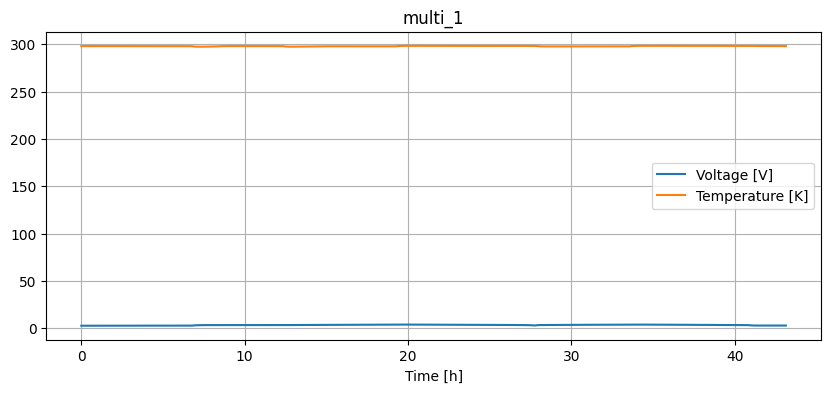

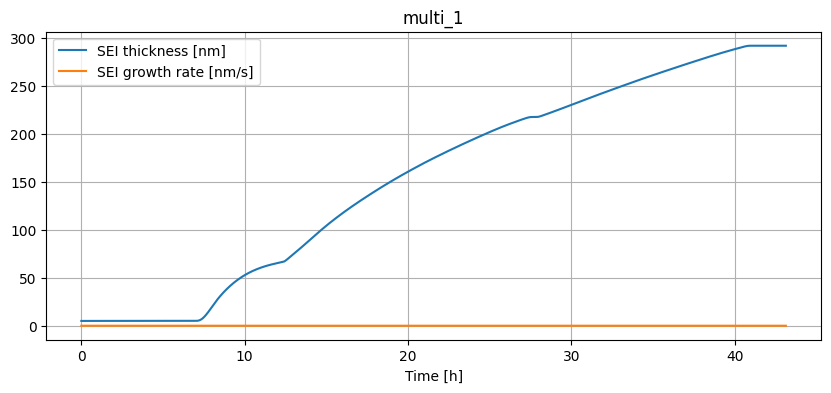

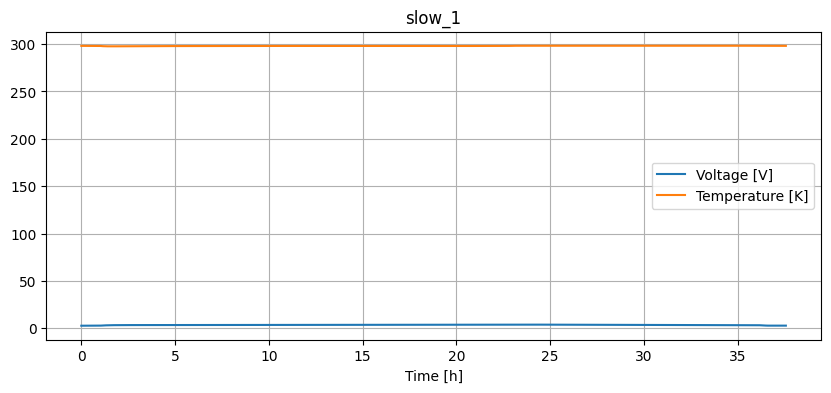

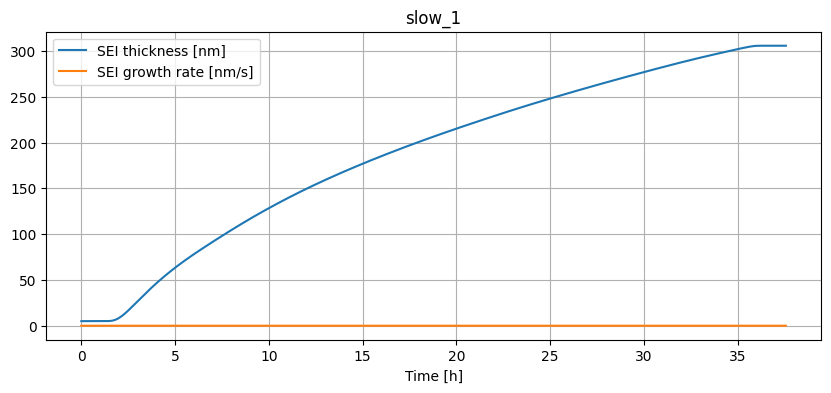

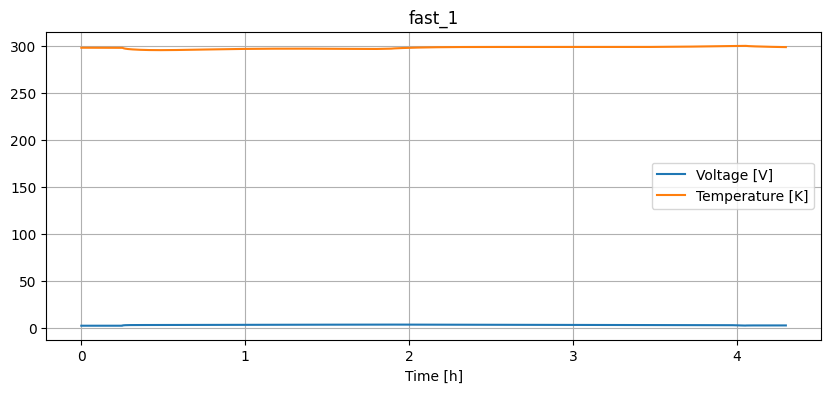

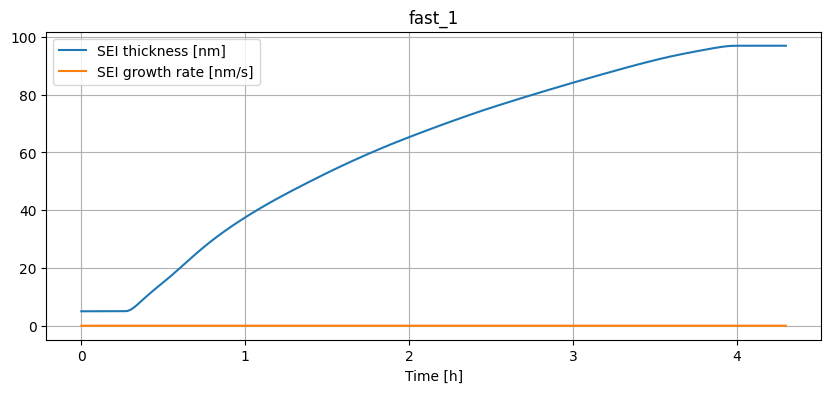

In [8]:
sample_names = ["multi_1", "slow_1", "fast_1"]

for name in sample_names:
    df = dataframes[name]
    time_h = df["Time [s]"] / 3600

    plt.figure(figsize=(10, 4))
    plt.plot(time_h, df["Terminal voltage [V]"], label="Voltage [V]")
    plt.plot(time_h, df["Cell temperature [K]"], label="Temperature [K]")
    plt.title(name)
    plt.xlabel("Time [h]")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(time_h, df["Negative SEI thickness [nm]"], label="SEI thickness [nm]")
    plt.plot(time_h, df["SEI growth rate [nm/s]"], label="SEI growth rate [nm/s]")
    plt.title(name)
    plt.xlabel("Time [h]")
    plt.legend()
    plt.grid(True)
    plt.show()


## 6. Define train / validation / test split

In [9]:
def split_name(protocol_id):
    if protocol_id in TRAIN_PROTOCOLS:
        return "train"
    if protocol_id in VAL_PROTOCOLS:
        return "val"
    if protocol_id in TEST_PROTOCOLS:
        return "test"
    raise ValueError(f"Unknown protocol id: {protocol_id}")


for name, df in dataframes.items():
    protocol_id = int(df["Protocol ID"].iloc[0])
    dataframes[name]["Split"] = split_name(protocol_id)

split_summary = []

for name, df in dataframes.items():
    split_summary.append({
        "dataset": name,
        "regime": df["Regime"].iloc[0],
        "protocol_id": int(df["Protocol ID"].iloc[0]),
        "split": df["Split"].iloc[0],
        "rows": len(df),
    })

split_df = pd.DataFrame(split_summary).sort_values(["regime", "protocol_id"])
split_df


,dataset,regime,protocol_id,split,rows
12,fast_1,fast,1,train,15473
13,fast_2,fast,2,train,12903
14,fast_3,fast,3,train,11017
15,fast_4,fast,4,train,12926
16,fast_5,fast,5,val,9542
17,fast_6,fast,6,test,12173
0,multi_1,multi,1,train,155258
1,multi_2,multi,2,train,181653
2,multi_3,multi,3,train,185483
3,multi_4,multi,4,train,134269


## 7. Normalization utilities

Normalization is fitted using **training datasets only**.


In [10]:
def fit_standardizer(dfs, columns):
    values = []
    for df in dfs:
        values.append(df[columns].values.astype(np.float32))
    values = np.vstack(values)

    mean = values.mean(axis=0)
    std = values.std(axis=0)
    std[std == 0] = 1.0

    return mean.astype(np.float32), std.astype(np.float32)


def transform_array(values, mean, std):
    return (values.astype(np.float32) - mean) / std


def save_scaler(path, input_cols, output_cols, x_mean, x_std, y_mean, y_std):
    scaler = {
        "input_cols": input_cols,
        "output_cols": output_cols,
        "x_mean": x_mean.tolist(),
        "x_std": x_std.tolist(),
        "y_mean": y_mean.tolist(),
        "y_std": y_std.tolist(),
    }
    with open(path, "w") as f:
        json.dump(scaler, f, indent=2)


## 8. Sequence-window construction

In [11]:
def create_windows_from_dataframe(
    df,
    input_cols,
    output_cols,
    input_length,
    prediction_horizon,
    stride,
    x_mean,
    x_std,
    y_mean,
    y_std,
):
    x_raw = df[input_cols].values.astype(np.float32)
    y_raw = df[output_cols].values.astype(np.float32)

    x_scaled = transform_array(x_raw, x_mean, x_std)
    y_scaled = transform_array(y_raw, y_mean, y_std)

    X_list = []
    Y_list = []
    start_indices = []

    max_start = len(df) - input_length - prediction_horizon

    for start in range(0, max_start + 1, stride):
        input_start = start
        input_end = start + input_length
        output_start = input_end
        output_end = input_end + prediction_horizon

        X_list.append(x_scaled[input_start:input_end])
        Y_list.append(y_scaled[output_start:output_end])
        start_indices.append(start)

    if len(X_list) == 0:
        return None, None, None

    X = np.stack(X_list).astype(np.float32)
    Y = np.stack(Y_list).astype(np.float32)
    start_indices = np.array(start_indices, dtype=np.int64)

    return X, Y, start_indices


def build_dataset_package(input_cols, package_name):
    train_dfs = [df for df in dataframes.values() if df["Split"].iloc[0] == "train"]

    x_mean, x_std = fit_standardizer(train_dfs, input_cols)
    y_mean, y_std = fit_standardizer(train_dfs, OUTPUT_COLS)

    all_X = {"train": [], "val": [], "test": []}
    all_Y = {"train": [], "val": [], "test": []}
    meta_rows = []

    for dataset_name, df in dataframes.items():
        split = df["Split"].iloc[0]
        X, Y, start_indices = create_windows_from_dataframe(
            df=df,
            input_cols=input_cols,
            output_cols=OUTPUT_COLS,
            input_length=INPUT_LENGTH,
            prediction_horizon=PREDICTION_HORIZON,
            stride=STRIDE,
            x_mean=x_mean,
            x_std=x_std,
            y_mean=y_mean,
            y_std=y_std,
        )

        if X is None:
            print(f"Skipping {dataset_name}: not enough rows.")
            continue

        all_X[split].append(X)
        all_Y[split].append(Y)

        for start_idx in start_indices:
            meta_rows.append({
                "dataset": dataset_name,
                "regime": df["Regime"].iloc[0],
                "protocol_id": int(df["Protocol ID"].iloc[0]),
                "split": split,
                "start_index": int(start_idx),
            })

        print(f"{dataset_name}: split={split}, X={X.shape}, Y={Y.shape}")

    output = {}

    for split in ["train", "val", "test"]:
        output[f"X_{split}"] = np.concatenate(all_X[split], axis=0)
        output[f"Y_{split}"] = np.concatenate(all_Y[split], axis=0)

    meta_df = pd.DataFrame(meta_rows)

    npz_path = PROCESSED_DIR / f"{package_name}.npz"
    scaler_path = PROCESSED_DIR / f"{package_name}_scaler.json"
    meta_path = PROCESSED_DIR / f"{package_name}_metadata.csv"

    np.savez_compressed(
        npz_path,
        **output,
        input_length=INPUT_LENGTH,
        prediction_horizon=PREDICTION_HORIZON,
        stride=STRIDE,
    )

    save_scaler(scaler_path, input_cols, OUTPUT_COLS, x_mean, x_std, y_mean, y_std)
    meta_df.to_csv(meta_path, index=False)

    print("\nSaved:")
    print(npz_path.resolve())
    print(scaler_path.resolve())
    print(meta_path.resolve())

    print("\nFinal shapes:")
    for key, value in output.items():
        print(key, value.shape)

    return output, meta_df


## 9. Build baseline-feature dataset

Inputs: current and terminal voltage only.


In [12]:
baseline_data, baseline_meta = build_dataset_package(
    input_cols=BASELINE_INPUT_COLS,
    package_name=f"seq2seq_baseline_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}",
)


multi_1: split=train, X=(31032, 50, 2), Y=(31032, 50, 3)
multi_2: split=train, X=(36311, 50, 2), Y=(36311, 50, 3)
multi_3: split=train, X=(37077, 50, 2), Y=(37077, 50, 3)
multi_4: split=train, X=(26834, 50, 2), Y=(26834, 50, 3)
multi_5: split=val, X=(37632, 50, 2), Y=(37632, 50, 3)
multi_6: split=test, X=(23461, 50, 2), Y=(23461, 50, 3)
slow_1: split=train, X=(27038, 50, 2), Y=(27038, 50, 3)
slow_2: split=train, X=(22037, 50, 2), Y=(22037, 50, 3)
slow_3: split=train, X=(17746, 50, 2), Y=(17746, 50, 3)
slow_4: split=train, X=(25496, 50, 2), Y=(25496, 50, 3)
slow_5: split=val, X=(17472, 50, 2), Y=(17472, 50, 3)
slow_6: split=test, X=(23157, 50, 2), Y=(23157, 50, 3)
fast_1: split=train, X=(3075, 50, 2), Y=(3075, 50, 3)
fast_2: split=train, X=(2561, 50, 2), Y=(2561, 50, 3)
fast_3: split=train, X=(2184, 50, 2), Y=(2184, 50, 3)
fast_4: split=train, X=(2566, 50, 2), Y=(2566, 50, 3)
fast_5: split=val, X=(1889, 50, 2), Y=(1889, 50, 3)
fast_6: split=test, X=(2415, 50, 2), Y=(2415, 50, 3)

Saved:

## 10. Build physics-informed-feature dataset

Inputs: current, terminal voltage, cumulative charge, and square-root cumulative charge.


In [13]:
physics_data, physics_meta = build_dataset_package(
    input_cols=PHYSICS_INPUT_COLS,
    package_name=f"seq2seq_physics_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}",
)


multi_1: split=train, X=(31032, 50, 4), Y=(31032, 50, 3)
multi_2: split=train, X=(36311, 50, 4), Y=(36311, 50, 3)
multi_3: split=train, X=(37077, 50, 4), Y=(37077, 50, 3)
multi_4: split=train, X=(26834, 50, 4), Y=(26834, 50, 3)
multi_5: split=val, X=(37632, 50, 4), Y=(37632, 50, 3)
multi_6: split=test, X=(23461, 50, 4), Y=(23461, 50, 3)
slow_1: split=train, X=(27038, 50, 4), Y=(27038, 50, 3)
slow_2: split=train, X=(22037, 50, 4), Y=(22037, 50, 3)
slow_3: split=train, X=(17746, 50, 4), Y=(17746, 50, 3)
slow_4: split=train, X=(25496, 50, 4), Y=(25496, 50, 3)
slow_5: split=val, X=(17472, 50, 4), Y=(17472, 50, 3)
slow_6: split=test, X=(23157, 50, 4), Y=(23157, 50, 3)
fast_1: split=train, X=(3075, 50, 4), Y=(3075, 50, 3)
fast_2: split=train, X=(2561, 50, 4), Y=(2561, 50, 3)
fast_3: split=train, X=(2184, 50, 4), Y=(2184, 50, 3)
fast_4: split=train, X=(2566, 50, 4), Y=(2566, 50, 3)
fast_5: split=val, X=(1889, 50, 4), Y=(1889, 50, 3)
fast_6: split=test, X=(2415, 50, 4), Y=(2415, 50, 3)

Saved:

## 11. Inspect processed data shapes

In [ ]:
for label, data in [("baseline", baseline_data), ("physics", physics_data)]:
    print("\n", label.upper())
    print("X_train:", data["X_train"].shape)
    print("Y_train:", data["Y_train"].shape)
    print("X_val:", data["X_val"].shape)
    print("Y_val:", data["Y_val"].shape)
    print("X_test:", data["X_test"].shape)
    print("Y_test:", data["Y_test"].shape)


## 12. Quick sanity plot of one output sequence

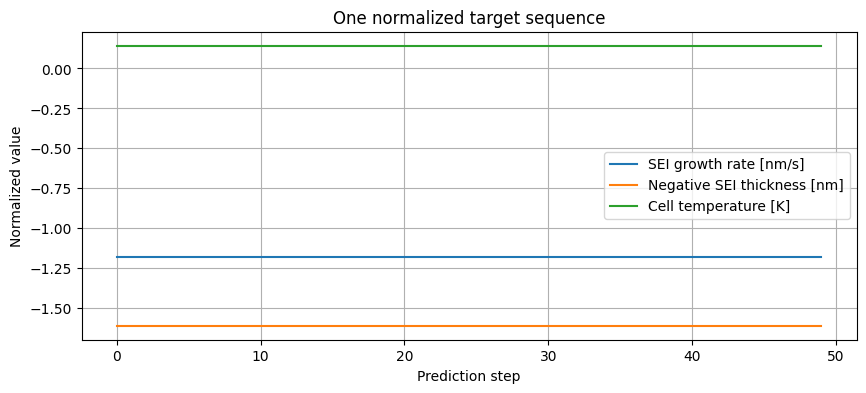

In [14]:
sample_idx = 0
Y_sample = physics_data["Y_train"][sample_idx]

plt.figure(figsize=(10, 4))
for i, col in enumerate(OUTPUT_COLS):
    plt.plot(Y_sample[:, i], label=col)

plt.title("One normalized target sequence")
plt.xlabel("Prediction step")
plt.ylabel("Normalized value")
plt.legend()
plt.grid(True)
plt.show()


## Done

After this notebook runs successfully, the next notebook should train the first surrogate model and continue further with other surrogate models.


NameError: name 'test_dfs' is not defined